# 02 · Windowing — raw signal → learnable examples

**Phase 2 goal:** turn each ~20 min recording into fixed-length, labelled windows a neural net can consume. The logic lives in `model/windowing.py` (imported here) so the training code and the cloud services all use the *same* windowing.

**Design decisions (approved):**
1. **One window per saccade** (600/subject) + **one per blink** (300/subject) = 900/subject.
2. **Length = 320 samples** = 64-sample pre-roll + 256 samples (~1.0 s) from onset. The pre-roll lets the model see the *starting baseline* (where drift lives).
3. **Gaze label = displacement in degrees**: forward `+T`, return `-T` (`displacement = target_after - target_before`).
4. **Blink head:** blink windows get `blink=1` and gaze `NaN` (masked from the gaze loss); saccade windows get `blink=0`.
5. **Normalisation = drift-preserving**: fixed global per-channel mean/std fit on the *train* subjects only — **not** per-window recentring (that would delete the drift we must keep).
6. **Split by subject** (leave-one-subject-out): every window keeps its subject id.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# find the repo root (the folder containing model/windowing.py) whether cwd is root or notebooks/
ROOT = next((p for p in [Path.cwd(), Path.cwd().parent] if (p / 'model' / 'windowing.py').exists()), None)
assert ROOT is not None, 'run from the repo root or notebooks/'
sys.path.insert(0, str(ROOT))

from model.windowing import (windows_for_subject, save_subject,
                             fit_normaliser, apply_normaliser,
                             WINDOW_LEN, PRE_ROLL, FS)

DATA = ROOT / 'data' / 'dataset1' / 'DATASET'
OUT = ROOT / 'data' / 'processed'
SUBJECTS = [f'S{i}' for i in range(1, 7)]
print('window length:', WINDOW_LEN, 'samples =', WINDOW_LEN / FS, 's  (pre-roll', PRE_ROLL, ')')

window length: 320 samples = 1.25 s  (pre-roll 64 )


## 1 · Build windows for every subject and save them

In [2]:
subject_windows = {}
for s in SUBJECTS:
    sw = windows_for_subject(DATA, s)
    subject_windows[s] = sw
    path = save_subject(OUT, sw)
    print(f'{s}: X={sw.X.shape}  saccade={(sw.y_blink==0).sum()}  '
          f'blink={(sw.y_blink==1).sum()}  -> {path.relative_to(ROOT)}')

total = sum(len(sw) for sw in subject_windows.values())
print(f'\ntotal windows: {total}')

S1: X=(900, 2, 320)  saccade=600  blink=300  -> data\processed\S1_windows.npz


S2: X=(900, 2, 320)  saccade=600  blink=300  -> data\processed\S2_windows.npz


S3: X=(900, 2, 320)  saccade=600  blink=300  -> data\processed\S3_windows.npz


S4: X=(900, 2, 320)  saccade=600  blink=300  -> data\processed\S4_windows.npz


S5: X=(900, 2, 320)  saccade=600  blink=300  -> data\processed\S5_windows.npz


S6: X=(900, 2, 320)  saccade=600  blink=300  -> data\processed\S6_windows.npz

total windows: 5400


## 2 · Verify the labels

A forward saccade and its return should be equal and opposite; blink windows should carry no gaze label.

In [3]:
sw = subject_windows['S1']
sacc = sw.y_gaze[sw.y_blink == 0]
print('first 4 saccade displacements (dx, dy) in degrees:')
for i in range(4):
    print('  ', sacc[i])
print('forward == -return ?', np.allclose(sacc[0], -sacc[1]), 'and', np.allclose(sacc[2], -sacc[3]))
print('blink windows have NaN gaze ?', np.isnan(sw.y_gaze[sw.y_blink == 1]).all())

first 4 saccade displacements (dx, dy) in degrees:
   [-3.8065367 -1.0377855]
   [3.8065367 1.0377855]
   [ 19.4707   -13.191815]
   [-19.4707    13.191815]
forward == -return ? True and True
blink windows have NaN gaze ? True


## 3 · Drift-preserving normaliser (fit on train subjects only)

We fit per-channel statistics on the training subjects and confirm the normaliser **keeps** the between-window baseline spread — i.e. it does not recentre each window and so leaves the drift in for the model + calibration to handle.

In [4]:
train_subs, heldout = SUBJECTS[:4], SUBJECTS[4:]  # illustrative split; real eval uses LOSO
Xtr = np.concatenate([subject_windows[s].X for s in train_subs])
mean, std = fit_normaliser(Xtr)
print(f'fit on {train_subs}:  mean={mean.ravel()}  std={std.ravel()}')

Xn = apply_normaliser(subject_windows[heldout[0]].X, mean, std)
win_means = Xn.mean(axis=2)  # each window's own mean, per channel
print(f'\n{heldout[0]} after normalising - spread of per-window means (should be > 0 = drift kept):')
print(f'  horizontal: {win_means[:,0].std():.3f}   vertical: {win_means[:,1].std():.3f}')

fit on ['S1', 'S2', 'S3', 'S4']:  mean=[-453.51297 -810.88586]  std=[ 834.2376 2567.9216]

S5 after normalising - spread of per-window means (should be > 0 = drift kept):
  horizontal: 1.381   vertical: 0.317


## 4 · Look at example windows

One forward saccade, one return saccade, and one blink — so we can see the fixed-length inputs the network will receive (dashed line = saccade/blink onset after the pre-roll).

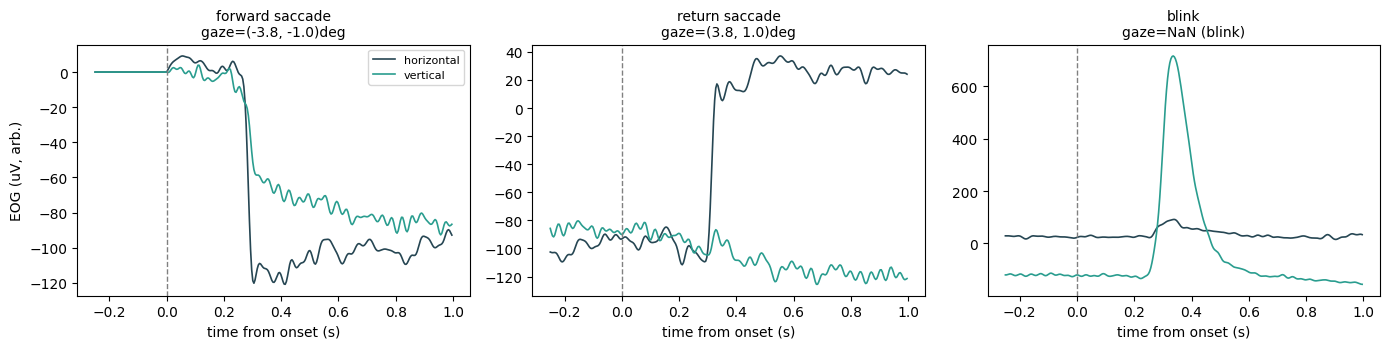

In [5]:
sw = subject_windows['S1']
sacc_idx = np.where(sw.y_blink == 0)[0]
blink_idx = np.where(sw.y_blink == 1)[0]
examples = [('forward saccade', sacc_idx[0]), ('return saccade', sacc_idx[1]), ('blink', blink_idx[0])]
t = (np.arange(WINDOW_LEN) - PRE_ROLL) / FS

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharex=True)
for ax, (title, idx) in zip(axes, examples):
    ax.plot(t, sw.X[idx, 0], color='#264653', lw=1.2, label='horizontal')
    ax.plot(t, sw.X[idx, 1], color='#2a9d8f', lw=1.2, label='vertical')
    ax.axvline(0, color='0.5', ls='--', lw=1)
    g = sw.y_gaze[idx]
    lbl = 'gaze=NaN (blink)' if np.isnan(g).any() else f'gaze=({g[0]:.1f}, {g[1]:.1f})deg'
    ax.set_title(f'{title}\n{lbl}', fontsize=10)
    ax.set_xlabel('time from onset (s)')
axes[0].set_ylabel('EOG (uV, arb.)')
axes[0].legend(fontsize=8, loc='best')
fig.tight_layout()
plt.show()

## Conclusions

- **5,400 windows** (900 × 6 subjects), each `(2, 320)`, saved to `data/processed/` with gaze + blink labels and a subject id.
- Labels verified: forward/return displacements are equal-and-opposite; blink windows carry no gaze.
- The normaliser rescales channels **without** erasing the drift, exactly as the method requires.

**Next → `03_train_base.ipynb` (Phase 3):** build the two-headed `GazeNet` (1D-CNN → BiLSTM → gaze head + blink head + drift adapter) and train the shared base model on the *seen* subjects (on Colab's free GPU), then record the honest before-calibration error on held-out subjects.